<a href="https://colab.research.google.com/github/Makkonenexe/CI345_Machine_Learning/blob/main/Lab10_DT_SVM_for_weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab10 - Decision Tree for Weather


# Step1: Loading Data


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [9]:
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

#Mount Google Drive
weather_file = '/content/drive/MyDrive/CI345_ML/Data/Weather.csv'
weather_table = pd.read_csv(weather_file)
weather_table.head(2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Day,Outlook,Temp,Humidity,Wind,PlayTennis
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No


# Step2: Basic Data Analysis

In [10]:
df = weather_table.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Day         14 non-null     object
 1   Outlook     14 non-null     object
 2   Temp        14 non-null     object
 3   Humidity    14 non-null     object
 4   Wind        14 non-null     object
 5   PlayTennis  14 non-null     object
dtypes: object(6)
memory usage: 804.0+ bytes


In [11]:
df.shape

(14, 6)

In [12]:
df.isnull().sum()

,0
Day,0
Outlook,0
Temp,0
Humidity,0
Wind,0
PlayTennis,0


# Step3: Data Visualization

<Axes: xlabel='PlayTennis'>

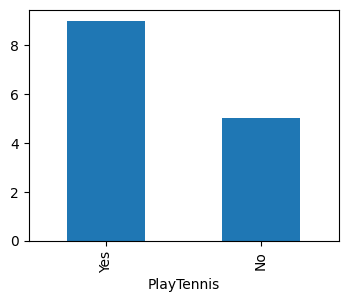

In [17]:
res = df.PlayTennis.value_counts()
res.plot(kind='bar', figsize = (4, 3))

# Step4: Processing data

In [16]:
# mehtod 1: Use LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Humidity'] = le.fit_transform(df['Humidity'])
df['Wind'] = le.fit_transform(df['Wind'])

df.head(1)

,Day,Outlook,Temp,Humidity,Wind,PlayTennis
0,D1,Sunny,Hot,0,1,No


In [23]:
print(df.Outlook.unique())
print(df.Temp.unique())

[nan]
[nan]


In [24]:
# mehtod 2: Use mapping method
df['Outlook'] = df['Outlook'].map({'Sunny': 0, 'Overcast': 1, 'Rain': 2})
df['Temp'] = df['Temp'].map({'Hot': 0, 'Mild': 1, 'Cool': 2})
df.head(14)

,Day,Outlook,Temp,Humidity,Wind,PlayTennis
0,D1,NaN,NaN,0,1,No
1,D2,NaN,NaN,0,0,No
2,D3,NaN,NaN,0,1,Yes
3,D4,NaN,NaN,0,1,Yes
4,D5,NaN,NaN,1,1,Yes
5,D6,NaN,NaN,1,0,No
6,D7,NaN,NaN,1,1,Yes
7,D8,NaN,NaN,0,1,No
8,D9,NaN,NaN,1,1,Yes
9,D10,NaN,NaN,1,0,Yes


# Step5: Get Data and target

In [26]:
data = df[['Outlook','Temp','Humidity','Wind']]
target = df['PlayTennis']
data.head(2)
target.head(2)


,PlayTennis
0,No
1,No


# Step6: Classification by DT

In [28]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (data, target, random_state = 13, test_size = 0.4)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)


(8, 4)
(6, 4)
(8,)
(6,)


In [32]:
# Step 4: Create a decision tree
from sklearn import tree
dt_classifier = tree.DecisionTreeClassifier(max_depth=4)

#Training the decision classifier
dt_classifier.fit (- data_train, y = target_train)
print(dt_classifier)

# Step 5: Testing
predicted = dt_classifier.predict(X= data_test)

# Step 6: Evaluation, Classification report
from sklearn.metrics import classification_report
report = classification_report (target_test, predicted)
print (report)



DecisionTreeClassifier(max_depth=4)
              precision    recall  f1-score   support

          No       0.33      1.00      0.50         2
         Yes       0.00      0.00      0.00         4

    accuracy                           0.33         6
   macro avg       0.17      0.50      0.25         6
weighted avg       0.11      0.33      0.17         6



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
